
# SmartCommerce AI — Regression Analysis & Model Benchmarking

## Diamond Price Prediction using Machine Learning

This notebook presents a complete end-to-end regression pipeline for predicting **diamond prices** using the SmartCommerce dataset. The workflow follows a production-style machine learning pipeline with reproducible preprocessing, detailed exploratory data analysis, feature engineering, model development, hyperparameter tuning, and performance evaluation.

### Objectives

- Perform comprehensive data auditing and cleaning.
- Conduct detailed Exploratory Data Analysis (EDA) with visual insights.
- Engineer meaningful features to improve predictive performance.
- Build and evaluate multiple regression algorithms using a consistent preprocessing pipeline.
- Compare models using **R² Score, RMSE, and MAE**.
- Prepare a modular notebook that can be extended with additional regression algorithms by team members.

> **Dataset:** Diamonds Dataset (SmartCommerce AI Capstone)


## 1. Import Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Load Dataset

The uploaded `diamonds.csv` file is tab-separated, so `sep="\t"` is required.

In [39]:
df = pd.read_csv("../data/diamonds.csv", sep="\t")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 3. Dataset Audit

We check the shape, data types, missing values, duplicates, and target distribution.

In [40]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of exact duplicate rows:", df.duplicated().sum())

print("\nTarget (price) summary:")
print(df["price"].describe())

Shape: (53940, 10)

Data types:
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

Missing values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Number of exact duplicate rows: 146

Target (price) summary:
count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64


### Insights — Dataset Audit

The initial audit verifies dataset dimensions, data types, missing values, and descriptive statistics. This step helps identify potential data quality issues before preprocessing.

**Key checks performed**

- Dataset shape and feature types.
- Missing-value analysis.
- Summary statistics for numerical variables.
- Target variable (`price`) overview.

## 4. Check Invalid Dimension Values

The physical dimensions `x`, `y`, and `z` should be greater than zero. We identify rows containing zero or negative values.

In [41]:
for col in ["x", "y", "z"]:
    print(f"{col} <= 0:", (df[col] <= 0).sum())

invalid_dimension_rows = (df[["x", "y", "z"]] <= 0).any(axis=1)
print("\nRows with at least one invalid dimension:", invalid_dimension_rows.sum())

x <= 0: 8
y <= 0: 7
z <= 0: 20

Rows with at least one invalid dimension: 20


### Insights — Invalid Dimension Values

The dataset contains physical dimensions (`x`, `y`, and `z`) representing the diamond's length, width, and depth.

Rows containing zero or unrealistic values are treated as invalid because they represent impossible diamond measurements. Removing these observations improves model reliability and reduces noise.

In [42]:
df = df.loc[~invalid_dimension_rows].copy()

print("Shape after removing invalid dimensions:", df.shape)

Shape after removing invalid dimensions: (53920, 10)


In [43]:
# Remove rows with physically implausible y/z values.
# These are data-entry errors (e.g. y=58.9mm when x=8.09mm suggests an extra
# digit was typed), not genuinely large diamonds — the max carat in this
# dataset (~2-5) cannot produce a 58.9mm or 31.8mm dimension.
outlier_rows = (df["y"] > 20) | (df["z"] > 10)
print("Extreme outlier rows found:", outlier_rows.sum())
df = df.loc[~outlier_rows].copy()

print("Shape after removing outlier rows:", df.shape)

Extreme outlier rows found: 3
Shape after removing outlier rows: (53917, 10)


## 5. Duplicate Check

The dataset contains exact duplicate rows. We check them explicitly. They are retained because a duplicate-looking observation is not automatically an error in a real-world dataset; removing them without evidence could discard valid observations.

In [44]:
print("Exact duplicate rows remaining:", df.duplicated().sum())

Exact duplicate rows remaining: 145


## 6. Duplicate Record Analysis

Duplicate records are checked before modeling to ensure that repeated observations do not bias evaluation metrics.

- Exact duplicates are identified.
- Duplicate rows are removed if present.
- The cleaned dataset is used for all subsequent analysis.

### EDA Roadmap

The exploratory analysis is organized into multiple stages:

1. Numerical feature distributions.
2. Categorical feature distributions.
3. Target variable analysis.
4. Correlation analysis.
5. Feature–target relationship analysis.
6. Outlier detection using boxplots.

Each visualization is followed by concise observations that explain its relevance to the regression problem.


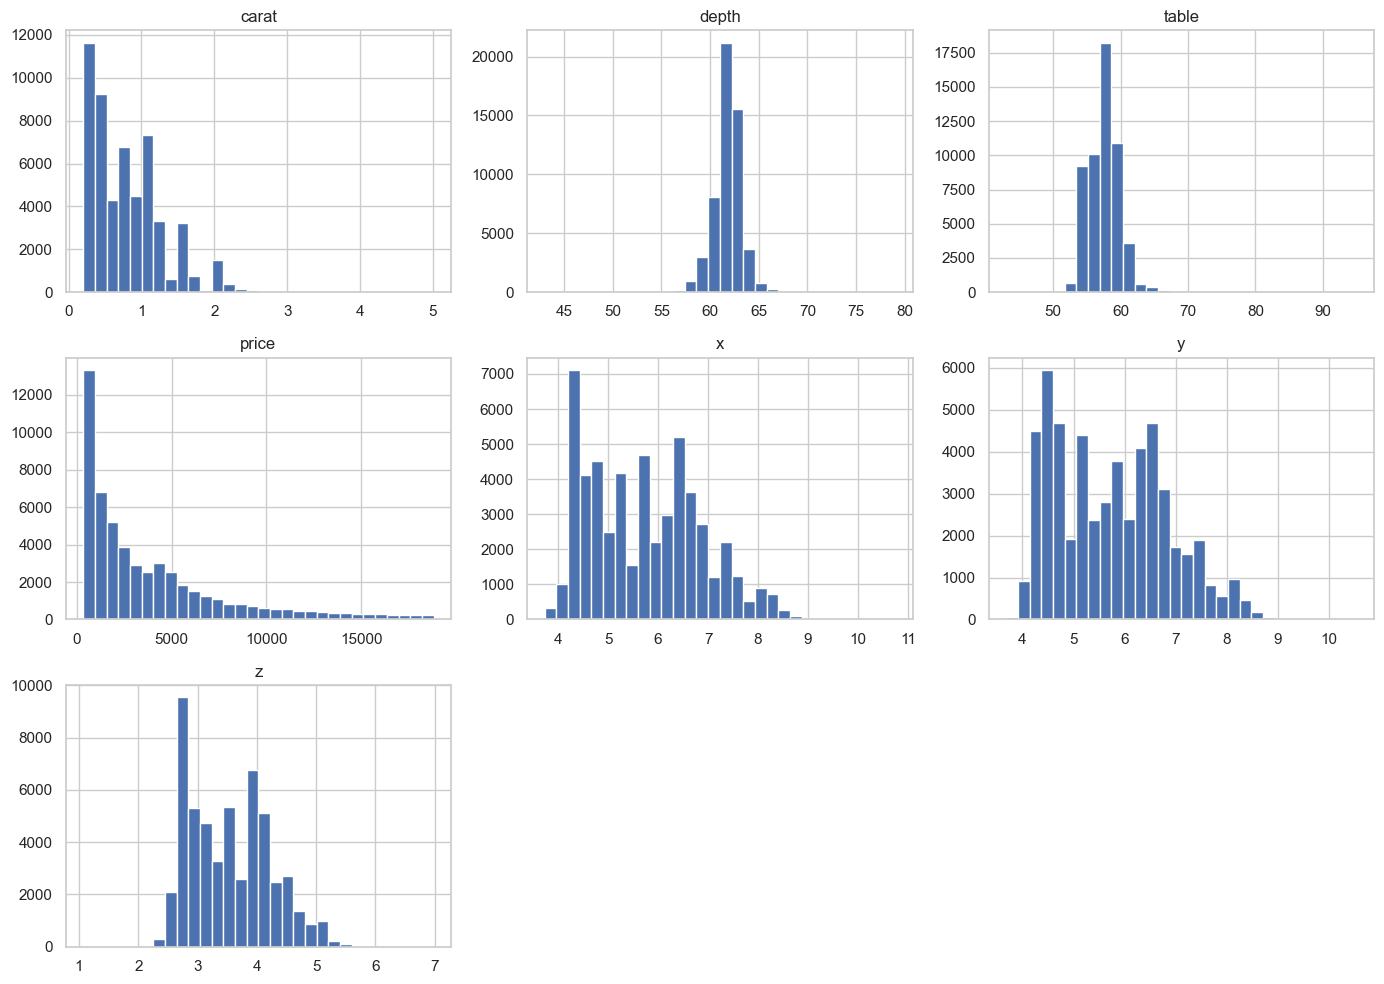

In [45]:
numerical_for_eda = df.select_dtypes(include=np.number).columns.tolist()

df[numerical_for_eda].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

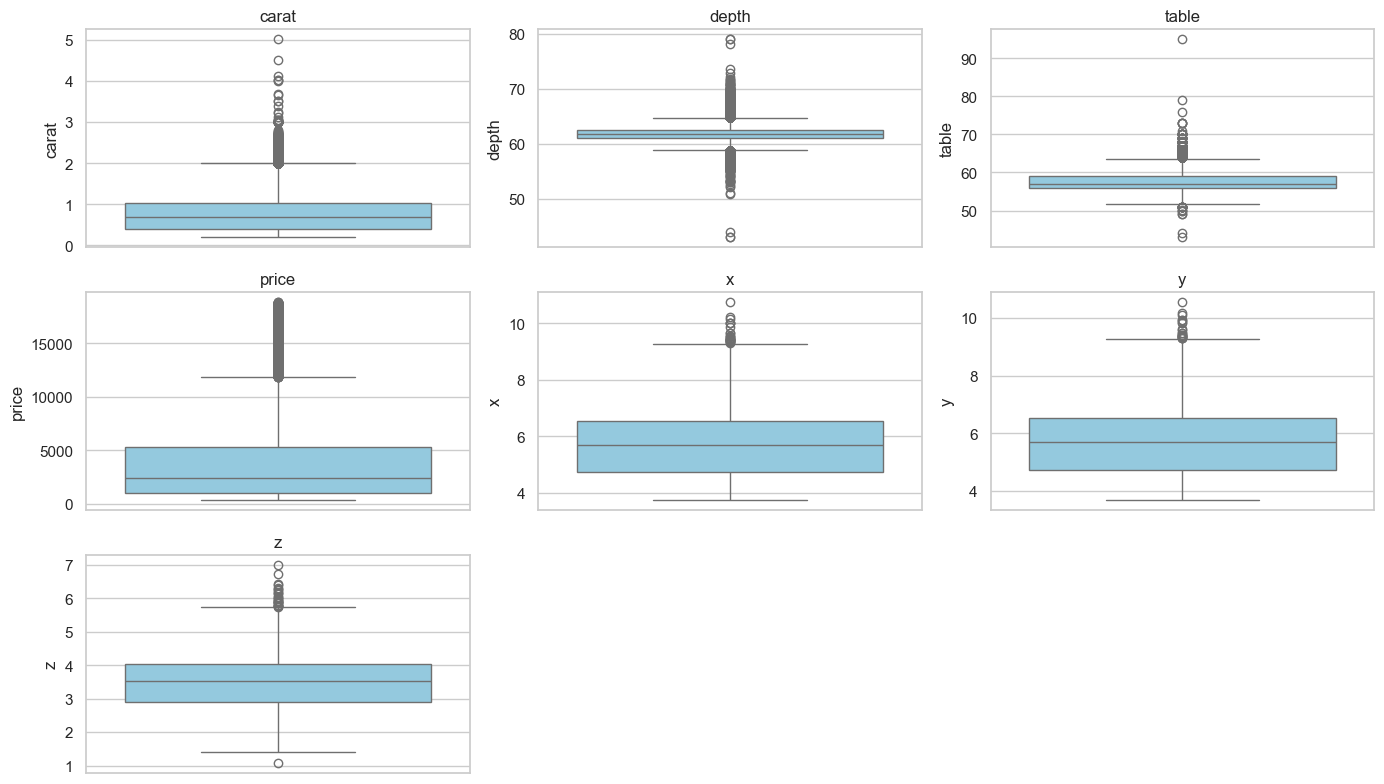

In [46]:

# Boxplots for Numerical Features (Outlier Detection)

plt.figure(figsize=(14, 8))
for i, column in enumerate(numerical_for_eda, 1):
    plt.subplot((len(numerical_for_eda)+2)//3, 3, i)
    sns.boxplot(y=df[column], color="skyblue")
    plt.title(column)

plt.tight_layout()
plt.show()


### Insights — Distribution of Numerical Features

Distribution plots help identify:

- Feature skewness.
- Outliers.
- Range and spread of each numerical attribute.
- Whether transformations may be required before modeling.

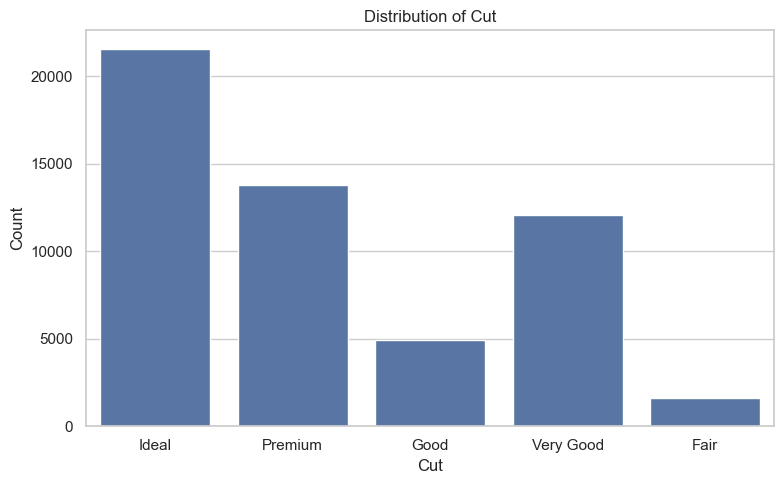

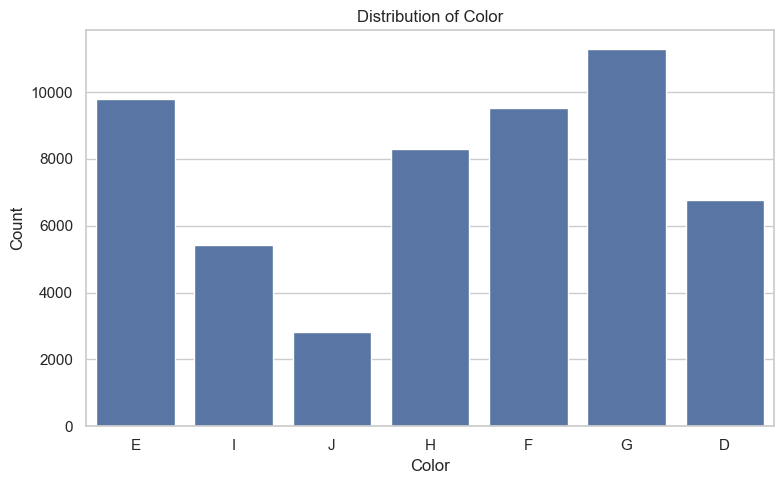

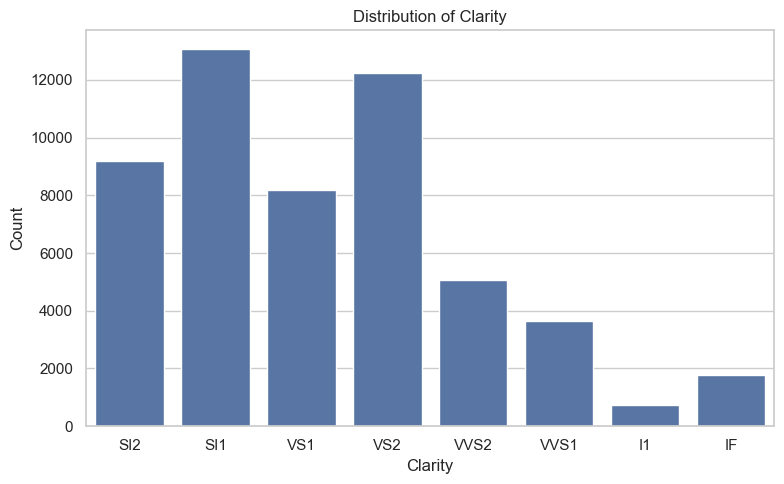

In [47]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="cut")
plt.title("Distribution of Cut")
plt.xlabel("Cut")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="color")
plt.title("Distribution of Color")
plt.xlabel("Color")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="clarity")
plt.title("Distribution of Clarity")
plt.xlabel("Clarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Insights — Distribution of Categorical Features

Categorical distributions reveal class imbalance and the frequency of different categories such as cut, color, and clarity.

These plots help determine whether categorical encoding is necessary and whether rare categories require special handling.

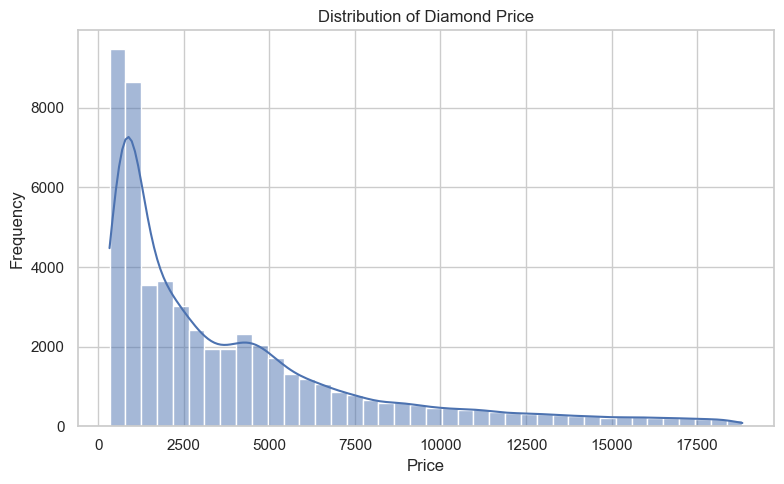

In [48]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Distribution of Diamond Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insights — Target Variable Distribution

The target variable (`price`) is visualized independently to understand:

- Overall distribution.
- Presence of skewness.
- Potential outliers.
- Suitability for regression modeling.

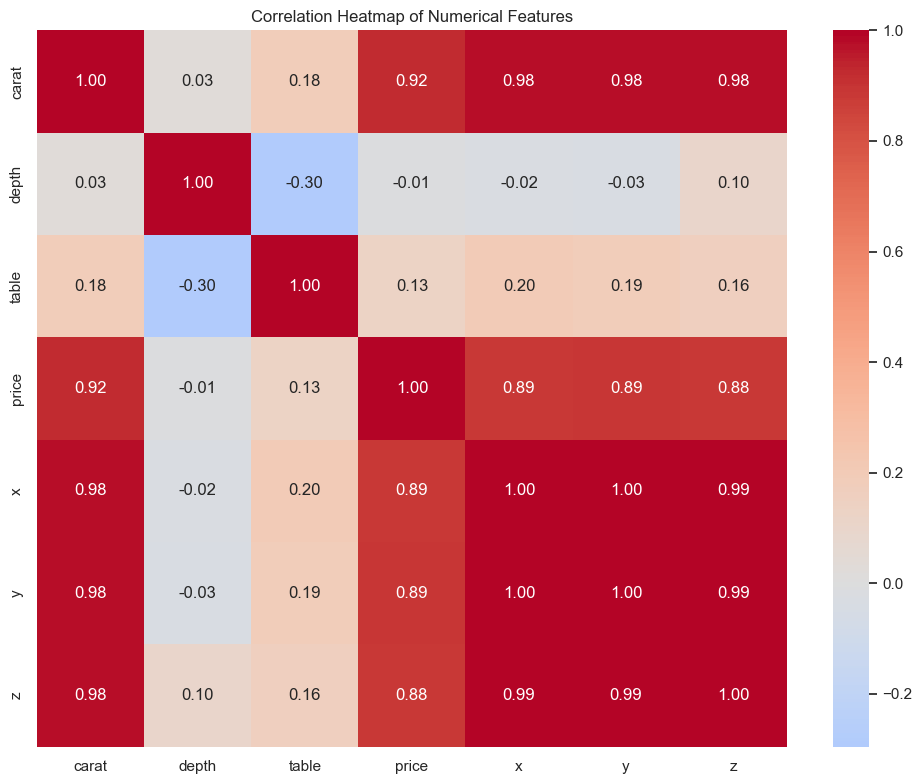

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[numerical_for_eda].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### Insights — Correlation Analysis

The correlation heatmap highlights linear relationships between numerical features.

The objective is to identify:

- Features strongly correlated with the target.
- Highly correlated predictor pairs.
- Potential multicollinearity.

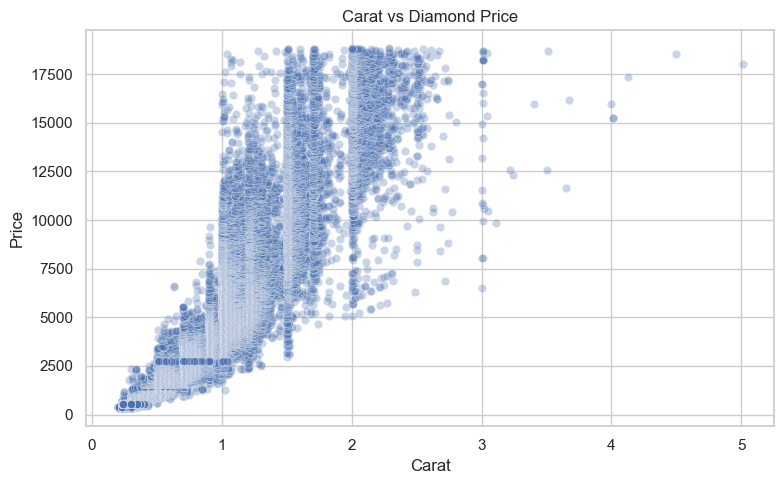

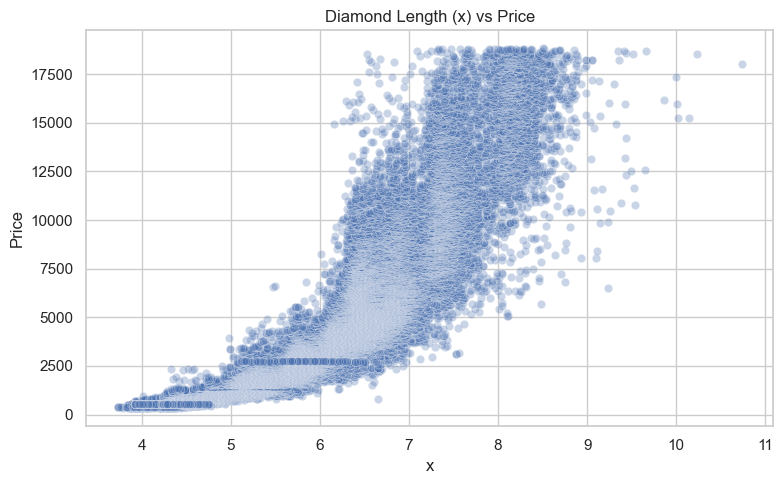

In [50]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="carat", y="price", alpha=0.3)
plt.title("Carat vs Diamond Price")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="x", y="price", alpha=0.3)
plt.title("Diamond Length (x) vs Price")
plt.xlabel("x")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### Insights — Feature Relationships with Price

Scatter plots visualize how important numerical attributes influence diamond price.

These relationships help identify trends, clusters, non-linearity, and heteroscedasticity.

## 7. Feature Engineering

Feature engineering introduces domain-informed variables that provide additional predictive information beyond the original dataset.

### Engineered Feature

**Volume**

<math block value="\text{Volume} = x \times y \times z"/>

This feature approximates the physical size of a diamond using its three dimensions. Larger diamonds generally command higher prices, making volume a useful predictor.

The engineered feature is added before preprocessing so every regression model uses the same feature space.

In [51]:
df["volume"] = df["x"] * df["y"] * df["z"]

df[["x", "y", "z", "volume", "price"]].head()

,x,y,z,volume,price
0,3.95,3.98,2.43,38.202030,326
1,3.89,3.84,2.31,34.505856,326
2,4.05,4.07,2.31,38.076885,327
3,4.20,4.23,2.63,46.724580,334
4,4.34,4.35,2.75,51.917250,335


## 8. Separate Features and Target

In [52]:
X = df.drop(columns=["price"])
y = df["price"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (53917, 10)
Target shape: (53917,)


## 9. Automatically Identify Numerical and Categorical Features

Feature types are detected from the dataframe instead of manually typing every column name. The detected lists are printed so they can be verified before preprocessing.

In [53]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
Categorical features: ['cut', 'color', 'clarity']


## 10. Stratified 80:20 Train-Test Split

For regression, the continuous target cannot be passed directly to `stratify`. Instead, the target is divided into quantile bins only for stratification. The actual regression target remains continuous.

`random_state=42` is used for reproducibility.

In [54]:
price_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=price_bins
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (43133, 10)
X_test : (10784, 10)
y_train: (43133,)
y_test : (10784,)


## 11. Data Preprocessing Pipeline

To ensure fair model comparison and avoid data leakage, preprocessing is performed using a single reusable pipeline.

### Numerical Features
- Missing value imputation using the median.
- Standardization using `StandardScaler`.

### Categorical Features
- Missing value imputation using the most frequent category.
- One-Hot Encoding with unknown-category handling.

The preprocessing pipeline is fit **only on the training dataset** and then applied to both training and testing datasets.

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (43133, 24)
Processed testing shape : (10784, 24)


## 12. Model Evaluation Utilities

A reusable evaluation function is created so that every regression algorithm is assessed using the same metrics.

### Evaluation Metrics

| Metric | Purpose |
|--------|---------|
| **R² Score** | Measures goodness of fit. Higher is better. |
| **RMSE** | Penalizes larger prediction errors. Lower is better. |
| **MAE** | Average absolute prediction error. Lower is better. |

Using identical evaluation logic ensures consistent benchmarking across all algorithms.

In [56]:
def evaluate_model(model_name, y_true, predictions):
    r2 = r2_score(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    mae = mean_absolute_error(y_true, predictions)

    print(f"{model_name}")
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print("-" * 40)

    return {
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    }

# Algorithm 1 — Linear Regression

Linear Regression is used as the baseline model.

The coefficients show how each processed feature is associated with the predicted price while the other features are held constant. Because numerical features are standardized, their coefficient magnitudes can be compared more meaningfully.

In [57]:
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

linear_pred = linear_model.predict(X_test_processed)

linear_result = evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)

Linear Regression
R²   : 0.9172
RMSE : 1151.3719
MAE  : 727.0397
----------------------------------------


### Interpreting Linear Regression Coefficients

Linear Regression serves as the baseline model.

Coefficient analysis helps understand:

- Which features positively influence price.
- Which features negatively influence price.
- Relative magnitude of feature influence after preprocessing.

In [58]:
linear_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

linear_coefficients.head(15)

,Feature,Coefficient
17,cat__clarity_IF,5157.557916
6,num__volume,4863.962408
22,cat__clarity_VVS1,4821.572893
23,cat__clarity_VVS2,4761.879179
20,cat__clarity_VS1,4407.727152
21,cat__clarity_VS2,4117.778359
18,cat__clarity_SI1,3518.711944
19,cat__clarity_SI2,2560.850125
16,cat__color_J,-2393.348861
5,num__z,-2278.217762


### Model Interpretation

The Linear Regression baseline establishes the reference performance for all subsequent regularized and non-linear regression models.

# Algorithm 2 — Ridge Regression

Ridge Regression adds L2 regularization. The required hyperparameter `alpha` will be tuned using GridSearchCV.

The tuned model is reported here, but it is **not compared/ranked against the other four algorithms**. The final comparison belongs to the complete 10-algorithm notebook.

In [59]:
ridge_model = Ridge()

ridge_param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_model,
    ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train_processed, y_train)

ridge_best = ridge_grid.best_estimator_
ridge_pred = ridge_best.predict(X_test_processed)

print("Best Ridge parameters:", ridge_grid.best_params_)
ridge_result = evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_pred
)

Best Ridge parameters: {'alpha': 0.1}
Ridge Regression
R²   : 0.9172
RMSE : 1151.3449
MAE  : 726.9888
----------------------------------------


### Hyperparameter Tuning — Ridge Regression

`GridSearchCV` searches multiple alpha values to identify the optimal regularization strength.

The tuned model is compared against the baseline Ridge model using identical evaluation metrics.

In [60]:
ridge_cv_results = pd.DataFrame(ridge_grid.cv_results_)

ridge_baseline_score = ridge_cv_results.loc[
    ridge_cv_results["param_alpha"].astype(float) == 1,
    "mean_test_score"
].iloc[0]

ridge_best_cv_score = ridge_grid.best_score_

print(f"Baseline alpha=1 CV R²: {ridge_baseline_score:.4f}")
print(f"Best alpha CV R²      : {ridge_best_cv_score:.4f}")
print(f"Improvement            : {ridge_best_cv_score - ridge_baseline_score:.4f}")

Baseline alpha=1 CV R²: 0.9232
Best alpha CV R²      : 0.9232
Improvement            : 0.0000


# Algorithm 3 — Lasso Regression

Lasso Regression uses L1 regularization. One useful property is that it can shrink some coefficients exactly to zero, producing a sparse model.

In [61]:
lasso_model = Lasso(max_iter=10000)

lasso_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso_model,
    lasso_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train_processed, y_train)

lasso_best = lasso_grid.best_estimator_
lasso_pred = lasso_best.predict(X_test_processed)

print("Best Lasso parameters:", lasso_grid.best_params_)
lasso_result = evaluate_model(
    "Lasso Regression",
    y_test,
    lasso_pred
)

Best Lasso parameters: {'alpha': 0.01}
Lasso Regression
R²   : 0.9172
RMSE : 1151.3601
MAE  : 726.9788
----------------------------------------


### Feature Sparsity in Lasso Regression

Lasso performs feature selection by shrinking some coefficients exactly to zero.

This section identifies how many encoded features remain active after regularization and discusses the sparsity introduced by the best alpha value.

In [62]:
zero_coefficients = np.sum(np.isclose(lasso_best.coef_, 0))

print("Total coefficients:", len(lasso_best.coef_))
print("Coefficients approximately equal to zero:", zero_coefficients)

Total coefficients: 24
Coefficients approximately equal to zero: 0


### Model Interpretation

Lasso helps identify the most influential predictors while reducing less informative encoded features.

# Algorithm 4 — ElasticNet Regression

ElasticNet combines L1 and L2 regularization.

The grid searches over both `alpha` and `l1_ratio`.

In [63]:
elastic_model = ElasticNet(max_iter=10000)

elastic_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1],
    "l1_ratio": [0.2, 0.5, 0.8]
}

elastic_grid = GridSearchCV(
    elastic_model,
    elastic_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

elastic_grid.fit(X_train_processed, y_train)

elastic_best = elastic_grid.best_estimator_
elastic_pred = elastic_best.predict(X_test_processed)

print("Best ElasticNet parameters:", elastic_grid.best_params_)
elastic_result = evaluate_model(
    "ElasticNet Regression",
    y_test,
    elastic_pred
)

Best ElasticNet parameters: {'alpha': 0.001, 'l1_ratio': 0.8}
ElasticNet Regression
R²   : 0.9172
RMSE : 1151.0039
MAE  : 723.6258
----------------------------------------


### Hyperparameter Tuning — ElasticNet

ElasticNet combines L1 and L2 regularization.

Grid Search tunes:

- Alpha
- L1 Ratio

The best parameter combination is selected using cross-validation.

In [64]:
elastic_cv_results = pd.DataFrame(elastic_grid.cv_results_)

baseline_mask = (
    elastic_cv_results["param_alpha"].astype(float).eq(0.01) &
    elastic_cv_results["param_l1_ratio"].astype(float).eq(0.5)
)

elastic_baseline_score = elastic_cv_results.loc[
    baseline_mask, "mean_test_score"
].iloc[0]

elastic_best_cv_score = elastic_grid.best_score_

print(f"Baseline (alpha=0.01, l1_ratio=0.5) CV R²: {elastic_baseline_score:.4f}")
print(f"Best ElasticNet CV R²                 : {elastic_best_cv_score:.4f}")
print(f"Improvement                            : {elastic_best_cv_score - elastic_baseline_score:.4f}")

Baseline (alpha=0.01, l1_ratio=0.5) CV R²: 0.9136
Best ElasticNet CV R²                 : 0.9230
Improvement                            : 0.0094


# Algorithm 5 — Polynomial Regression

Polynomial Regression is implemented using `PolynomialFeatures` followed by Linear Regression.

Degrees 2 and 3 are compared **within the Polynomial Regression algorithm only**, because the guideline asks to compare polynomial degrees. This is not the final comparison of Algorithms 1–5.

In [65]:
polynomial_results = []

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train_processed)
    X_test_poly = poly.transform(X_test_processed)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    poly_pred = poly_model.predict(X_test_poly)

    result = evaluate_model(
        f"Polynomial Regression (Degree {degree})",
        y_test,
        poly_pred
    )

    polynomial_results.append({
        "Degree": degree,
        "R2": result["R2"],
        "RMSE": result["RMSE"],
        "MAE": result["MAE"]
    })

Polynomial Regression (Degree 2)
R²   : 0.9674
RMSE : 721.7671
MAE  : 400.9308
----------------------------------------
Polynomial Regression (Degree 3)
R²   : -9.9819
RMSE : 13256.6952
MAE  : 533.3859
----------------------------------------


In [66]:
polynomial_degree_results = pd.DataFrame(polynomial_results)
polynomial_degree_results

,Degree,R2,RMSE,MAE
0,2,0.967446,721.767105,400.930805
1,3,-9.981944,13256.695200,533.385917


### Polynomial Regression Analysis

Polynomial features allow Linear Regression to model non-linear relationships.

Different polynomial degrees are evaluated and compared using the same train-test split to identify the best trade-off between bias and variance.

# Algorithm 6--- Decision Tree Regressor

A tree-based regression model that splits the data into smaller groups based on feature values to predict the target price. The maximum tree depth is tuned using GridSearchCV to control model complexity and reduce overfitting.

In [67]:
''
# Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)

dt_param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10]
}

dt_grid = GridSearchCV(
    dt_model,
    dt_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

dt_grid.fit(X_train_processed, y_train)

dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test_processed)

print("Best Decision Tree parameters:", dt_grid.best_params_)

dt_result = evaluate_model(
    "Decision Tree Regressor",
    y_test,
    dt_pred
)

Best Decision Tree parameters: {'max_depth': 10}
Decision Tree Regressor
R²   : 0.9500
RMSE : 894.8065
MAE  : 452.6866
----------------------------------------


## Feature Importance
This analysis shows the most important features used by the Decision Tree to predict diamond price. The features are arranged from highest to lowest importance, and the top 5 features are displayed.


In [68]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_best.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(5)

,Feature,Importance
6,num__volume,0.646143
4,num__y,0.259661
19,cat__clarity_SI2,0.019747
18,cat__clarity_SI1,0.013666
0,num__carat,0.011551


# Algorithm 7--- Random Forest Regressor
An ensemble regression model that combines multiple Decision Trees and averages their predictions to improve accuracy and reduce overfitting. The number of trees (n_estimators) is tuned using GridSearchCV.

In [69]:

rf_model = RandomForestRegressor(
    random_state=42
)

rf_param_grid = {
    "n_estimators": [50, 100, 150, 200]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test_processed)

print("Best Random Forest parameters:", rf_grid.best_params_)

rf_result = evaluate_model(
    "Random Forest Regressor",
    y_test,
    rf_pred
)

Best Random Forest parameters: {'n_estimators': 150}
Random Forest Regressor
R²   : 0.9760
RMSE : 619.9220
MAE  : 291.8451
----------------------------------------


# Algorithm 8--- Gradient Boosting Regressor
An ensemble regression model that builds Decision Trees sequentially, where each new tree attempts to correct the errors of the previous trees. The learning_rate is tuned using GridSearchCV to improve model performance.

In [70]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    gb_model,
    gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train_processed, y_train)

gb_best = gb_grid.best_estimator_
gb_pred = gb_best.predict(X_test_processed)

print("Best Gradient Boosting parameters:", gb_grid.best_params_)

gb_result = evaluate_model(
    "Gradient Boosting Regressor",
    y_test,
    gb_pred
)

Best Gradient Boosting parameters: {'learning_rate': 0.2}
Gradient Boosting Regressor
R²   : 0.9621
RMSE : 778.9946
MAE  : 392.5725
----------------------------------------


# Algorithm 9--- Support Vector Regressor(SVR)
A regression algorithm that predicts continuous values by finding a function that keeps prediction errors within an acceptable margin. In this project, C and kernel are tuned using GridSearchCV to improve prediction performance.

In [71]:
svr_model = SVR(epsilon=0.1)

# Hyperparameter tuning
svr_param_grid = {
    "C": [1, 10, 100],
    "kernel": ["linear", "rbf"]
}

svr_grid = GridSearchCV(
    svr_model,
    svr_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train the model
svr_grid.fit(X_train_processed, y_train)

# Get the best model
svr_best = svr_grid.best_estimator_

# Predict on test data
svr_pred = svr_best.predict(X_test_processed)

# Display best parameters
print("Best SVR parameters:", svr_grid.best_params_)

# Evaluate the model
svr_result = evaluate_model(
    "Support Vector Regressor",
    y_test,
    svr_pred
)

Best SVR parameters: {'C': 100, 'kernel': 'rbf'}
Support Vector Regressor
R²   : 0.9476
RMSE : 916.1012
MAE  : 414.2216
----------------------------------------


# Algorithm 10--- K-Nearest NeighbourRegressor
A regression algorithm that predicts the target value by finding the nearest data points and averaging their target values. The number of neighbors (k) is tuned using GridSearchCV, and feature scaling is important because KNN uses distances between data points.

In [72]:
knn_model = KNeighborsRegressor()

# Hyperparameter tuning
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11]
}

knn_grid = GridSearchCV(
    knn_model,
    knn_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train the model
knn_grid.fit(X_train_processed, y_train)

# Get the best model
knn_best = knn_grid.best_estimator_

# Predictions
knn_pred = knn_best.predict(X_test_processed)

# Best parameter
print("Best KNN parameters:", knn_grid.best_params_)

# Evaluation
knn_result = evaluate_model(
    "K-Nearest Neighbors Regressor",
    y_test,
    knn_pred
)

Best KNN parameters: {'n_neighbors': 5}
K-Nearest Neighbors Regressor
R²   : 0.9575
RMSE : 824.7985
MAE  : 409.3226
----------------------------------------
